In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import time

In [138]:
spec_size = int(2*512)
hspc_size = int(spec_size/2)
#central_freq = 19/(.6*2) #15.833
#central_freq = 15.707963268 #5pi
central_freq = 2*2.5*np.pi
range_freq = central_freq

numbr_frequencies = 41
initi_frequencies = 20
final_frequencies = 100
parti_frequencies = 41
converge = 3

filename = '_' + str(numbr_frequencies) + '_' + str(initi_frequencies) + '_' + str(final_frequencies) + '.h5'
pathname = '/home/amsj/Octave/DPSM/publish/dpsm_ultrasound_propag-git/octave/'

mu, sigma = 0, 0.2

In [139]:
x = np.arange(0.0,1,0.00625)[:,None]
x_size = np.size(x,axis=0)
dom = np.linspace(-.5,.5,x_size)
gauss = 1/(sigma * np.sqrt(2.0 * np.pi)) * np.exp( - (dom - mu)**2 / (2 * sigma**2) )[:,None]

central_range = range_freq*dom + central_freq

In [84]:
def synth_fseries_from_centr_freq(cent_freq):
    osc = np.sin(cent_freq*np.pi*x)
    spec = np.fft.fft(osc*gauss,n=spec_size,axis=0)
    freq = np.fft.fftfreq(spec_size)

    return osc,freq,spec

In [85]:
def load_para():
    
    f = h5py.File(pathname + 'PP' + filename,'r')

    gridx = f['b']['value']['A']['value']['x']['value']

    gridy = f['b']['value']['A']['value']['z']['value']

    grid = np.empty(gridx.shape,dtype='complex')

    grid.real = gridx;grid.imag = gridy
    
    return grid/f['nRD']['value']

In [86]:
def load_resp(converge):
    
    f = h5py.File(pathname + 'resp_enh_' + str(converge) +  filename,'r')

    resp = np.array(f['resp']['value']).view(np.complex)

    return resp

In [87]:
def load_doma(converge):
    
    f = h5py.File(pathname + 'doma_enh_' + str(converge) +  filename,'r')

    doma = np.array(f['doma']['value']).view(np.complex)

    return doma

In [88]:
def load_(para,converge):
    
    f = h5py.File(pathname + para + '_enh_' + str(converge) +  filename,'r')

    dataset = f[para]['value']
    
    list_keys = list(dataset.keys())
    
    dims = tuple(dataset[list_keys[-1]])

    return dataset,dims

In [89]:
def expand_resp_0(resp):
    leading_size = int(initi_frequencies/(final_frequencies-initi_frequencies)*(numbr_frequencies-1))
    leading_zero = np.zeros((leading_size,1))
    trailing_size = int(hspc_size-parti_frequencies-leading_size)
    trailing_zero = np.zeros((trailing_size,1))
    new_resp = np.empty((spec_size,1),dtype='complex')
    flip_resp = np.flip(resp,axis=0)
    new_resp.real = np.vstack((
        leading_zero,
        resp[:,np.newaxis].real,
        trailing_zero,
        trailing_zero,
        flip_resp[:,np.newaxis].real,
        leading_zero)
    )

    new_resp.imag = np.vstack((
        leading_zero,
        resp[:,np.newaxis].imag,
        trailing_zero,
        trailing_zero,
        -flip_resp[:,np.newaxis].imag,
        leading_zero)
    )
    return new_resp

In [90]:
def expand_resp_1(resp):
    leading_size = int(initi_frequencies/(final_frequencies-initi_frequencies)*(numbr_frequencies-1))
    leading_zero = np.zeros((leading_size,resp.shape[1]))
    #print(leading_size)
    trailing_size = int(hspc_size-parti_frequencies-leading_size)
    trailing_zero = np.zeros((trailing_size,resp.shape[1]))
    #print(trailing_size)
    new_resp = np.empty((spec_size,resp.shape[1]),dtype='complex')
    flip_resp = np.flip(resp,axis=0)
    #print(2*(trailing_size+leading_size+resp.shape[0]))
    new_resp.real = np.vstack((
        leading_zero,
        resp.real,
        trailing_zero,
        trailing_zero,
        flip_resp.real,
        leading_zero)
    )

    new_resp.imag = np.vstack((
        leading_zero,
        resp.imag,
        trailing_zero,
        trailing_zero,
        -flip_resp.imag,
        leading_zero)
    )
    return new_resp

In [91]:
def expand_resp_2(resp):
    leading_size = int(initi_frequencies/(final_frequencies-initi_frequencies)*(numbr_frequencies-1))
    leading_zero = np.zeros((leading_size,resp.shape[1],resp.shape[2]))

    trailing_size = int(hspc_size-leading_size-parti_frequencies)
    trailing_zero = np.zeros((trailing_size,resp.shape[1],resp.shape[2]))

    new_resp = np.empty((spec_size,resp.shape[1],resp.shape[2]),dtype='complex')

    new_resp.real = np.vstack((
        leading_zero,
        resp.real,
        trailing_zero,
        trailing_zero,
        resp[::-1].real,
        leading_zero)
    )

    new_resp.imag = np.vstack((
        leading_zero,
        resp.imag,
        trailing_zero,
        trailing_zero,
        -resp[::-1].imag,
        leading_zero)
    )
    return new_resp

In [92]:
def synth_tseries(new_resp,cent_freq):
    osc = np.sin(cent_freq*np.pi*x)

    spec = np.fft.fft(osc*gauss,n=spec_size,axis=0)
    freq = np.fft.fftfreq(spec_size)

    new_full = new_resp*spec[:, np.newaxis]
    tseries = np.fft.ifft(new_full,n=spec_size,axis=0)
    return osc,new_full,tseries

In [93]:
def synth_tseries_from_spec(new_resp,spec):
    new_full = new_resp*spec
    tseries = np.fft.ifft(new_full,n=spec_size,axis=0)
    return new_full,tseries

In [94]:
def plt_arrange(ii):
    
    osc,new_full,tseries = synth_tseries(central_range[ii])
    #axs = plt.figure().subplots(3,1)
    '''
    ax = fig.add_subplot(gs[0,0])
    ax.plot(x,osc*gauss)
    ax.set_title('pulse')

    ax = fig.add_subplot(gs[:,2])
    ax.imshow(abs(new_full[:,0,:]))
    ax.set_title('spectrum vs distance')

    ax = fig.add_subplot(gs[:,1])
    ax.imshow(tseries[:,0,:].real)
    ax.set_title('a-scan vs distance')
    
    ax = fig.add_subplot(gs[:,0])
    ax.imshow(abs(new_resp))
    ax.set_title('spectrum vs distance')
    
    ax = fig.add_subplot(gs[1,0])
    ax.plot(np.max(abs(tseries),axis=0))
    ax.set_title('max vs distance')
    '''
    plt.plot(np.max(abs(tseries),axis=0).transpose())
    #plt.show()
    plt.savefig('tseries' + str(ii) + '.png')
    plt.clear(True)

In [95]:
def plt_max_tseries(converge):
    resp = load_resp(converge)
    new_resp = expand_resp_2(resp)
    max_tseries = np.empty((x_size,new_resp.shape[2],new_resp.shape[1]),dtype='double')
    #mat_tseries = np.empty((x_size,new_resp.shape[0],new_resp.shape[1],new_resp.shape[2]),dtype='complex')
     
    for ii in range(x_size):
        osc,new_full,tseries = synth_tseries(new_resp,central_range[ii])
        max_tseries[ii,:,:] = np.max(abs(tseries),axis=0).transpose()
        #mat_tseries[ii,:,:,:] = tseries
    #return mat_tseries
    return max_tseries

In [96]:
def plt_mat_tseries_1(converge):
    resp = load_resp(converge)
    
    #max_tseries = np.empty((x_size,new_resp.shape[2],new_resp.shape[1]),dtype='double')
    #mat_tseries = np.empty((x_size,spec_size,resp.shape[1],resp.shape[2]),dtype='complex')
    mat_tseries = np.empty((x_size,resp.shape[2]),dtype='complex')
     
    for ii in range(int(x_size)):
        osc,freq,spec = synth_fseries_from_centr_freq(central_range[ii])
        for jj  in range(int(resp.shape[2])):
            new_resp = expand_resp_1(resp[:,:,jj])
            new_full,tseries = synth_tseries_from_spec(new_resp,spec)
            tsumseries = np.sum(tseries,axis=-1)
            tstdseries = np.std(tsumseries)
        #max_tseries[ii,:,:] = np.max(abs(tseries),axis=0).transpose()
            mat_tseries[ii,jj] = tstdseries
    return mat_tseries
    #return max_tseries

In [100]:
%matplotlib notebook

In [77]:
doma_dataset,doma_dims = load_('doma',0)

doma_list_keys = list(doma_dataset.keys())
doma_data = np.array(doma_dataset[doma_list_keys[0]]['value']).view(np.complex)

resp_dataset,resp_dims = load_('resp',0)

resp_list_keys = list(resp_dataset.keys())
resp_data = np.array(resp_dataset[resp_list_keys[0]]['value']).view(np.complex)

grid = load_para()

<IPython.core.display.Javascript object>


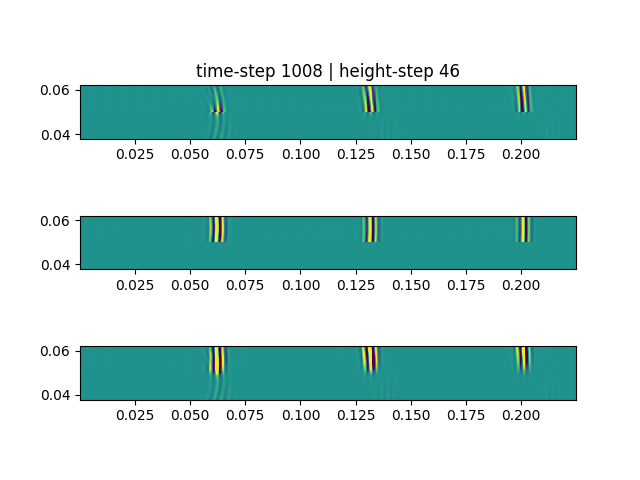

<ipython-input-167-3e1c23dc276e>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  h0 = axs[0].pcolormesh(this_grid.real,this_grid.imag,this_series)
<ipython-input-167-3e1c23dc276e>:11: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  h1 = axs[1].pcolormesh(this_grid.real,this_grid.imag,this_series)
<ipython-input-167-3e1c23dc276e>:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specif

<IPython.core.display.Javascript object>


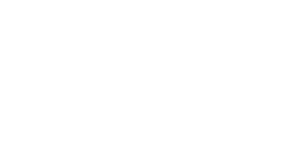

In [167]:
# Testing t-domain analysis on grid
this_time_ndx = 0
fg,axs = plt.subplots(3,1)
#this_series = 20*np.log10(abs(mat_tseries[this_time_ndx,:]))
#this_series = np.ones((1,doma_data.shape[1]))
this_series = mat_tseries[this_time_ndx,:,2].real
#this_series = this_doma[:,0]
this_grid = grid
this_series.shape = this_grid.shape
h0 = axs[0].pcolormesh(this_grid.real,this_grid.imag,this_series)
h1 = axs[1].pcolormesh(this_grid.real,this_grid.imag,this_series)
h2 = axs[2].pcolormesh(this_grid.real,this_grid.imag,this_series)
axs[0].set_aspect('equal', 'box')
axs[1].set_aspect('equal', 'box')
axs[2].set_aspect('equal', 'box')
#fg.canvas.draw()
mat_tseries = np.empty((spec_size,doma_data.shape[1],3),dtype='complex')

for ii in range(0+1*int(1*x_size/160),1+1*int(1*x_size/160),1):
    osc,freq,spec = synth_fseries_from_centr_freq(central_range[ii])
    for jj in range(0,int(doma_dims[0]),23):
        index = np.ravel_multi_index((jj,0),doma_dims)
        doma_data = np.array(doma_dataset[doma_list_keys[index]]['value']).view(np.complex)
        index = np.ravel_multi_index((jj,1),doma_dims)
        doma_data += np.array(doma_dataset[doma_list_keys[index]]['value']).view(np.complex)
        index = np.ravel_multi_index((jj,2),doma_dims)
        doma_data0 = np.array(doma_dataset[doma_list_keys[index]]['value']).view(np.complex)
        doma_data1 = doma_data0 + doma_data
        #domat = doma[:,:,jj*8]
        for kk in range(int(doma_data.shape[1])):
            domatt = doma_data[:,kk].transpose()
            new_doma = expand_resp_0(domatt)
            new_full,tseries = synth_tseries_from_spec(new_doma,spec)
            mat_tseries[:,kk,0] = tseries.transpose()
            domatt = doma_data0[:,kk].transpose()
            new_doma = expand_resp_0(domatt)
            new_full,tseries = synth_tseries_from_spec(new_doma,spec)            
            mat_tseries[:,kk,1] = tseries.transpose()
            domatt = doma_data1[:,kk].transpose()
            new_doma = expand_resp_0(domatt)
            new_full,tseries = synth_tseries_from_spec(new_doma,spec)            
            mat_tseries[:,kk,2] = tseries.transpose()            
        for ll in range(int(spec_size/16)):
            this_series = mat_tseries[ll*16,:,0].real
            #this_series = 20*np.log10(abs(mat_tseries[ll,:]))
            this_series.shape = this_grid.shape
            
            h0.set_array(this_series[:-1,:-1].ravel())
            
            this_series = mat_tseries[ll*16,:,1].real
            #this_series = 20*np.log10(abs(mat_tseries[ll,:]))
            this_series.shape = this_grid.shape            
            h1.set_array(this_series[:-1,:-1].ravel())
            
            this_series = mat_tseries[ll*16,:,2].real
            #this_series = 20*np.log10(abs(mat_tseries[ll,:]))
            this_series.shape = this_grid.shape            
            h2.set_array(this_series[:-1,:-1].ravel())            
            
            axs[0].set_title('time-step ' + str(ll*16) + ' | height-step ' + str(jj))
            #domat.shape

            #plt.draw()
            time.sleep(1e-4)
            #clear_output(wait=False)
            #plt.show()#draw();
            fg.canvas.draw()
            #plt.grid(True

<IPython.core.display.Javascript object>


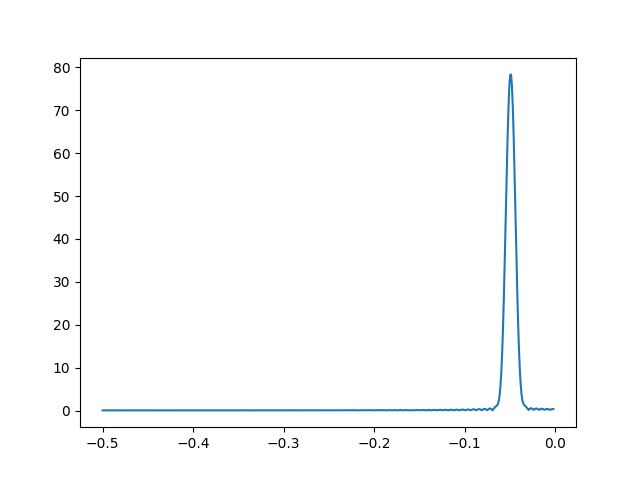

<IPython.core.display.Javascript object>


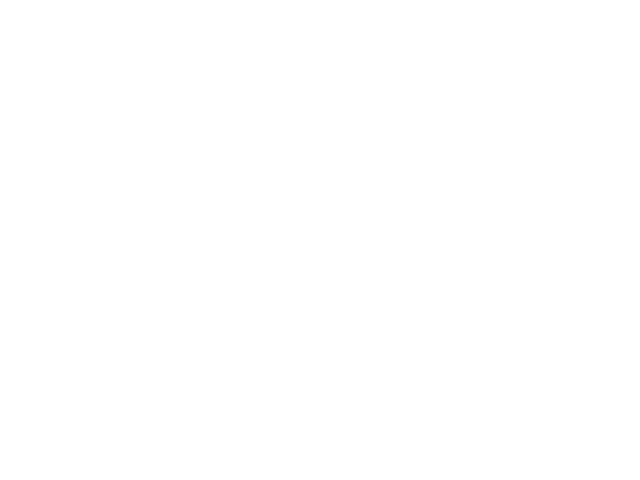

In [165]:
osc,freq,spec = synth_fseries_from_centr_freq(central_range[int(x_size/2)])
fg,ax = plt.subplots(1,1)
ax.plot(freq[hspc_size:-1],abs(spec[hspc_size:-1]))
fg.canvas.draw()

In [ ]:
#domat = np.sum(doma[-1,:,:],axis=0)
#domat = doma[-1,:,-1]
mat_tseries.shape = grid.shape
#domat.shape
plt.pcolormesh(grid.real, grid.imag, mat_tseries.real, shading='nearest')
#plt.grid(True)
plt.axis('scaled')
plt.title("Error (dB)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
#plt.imshow(abs(domat).transpose())

In [ ]:
mat_tseries_4 = plt_mat_tseries_1(4)

In [157]:
def plt_mat_tseries_2(converge):
    resp = load_resp(converge)
    new_resp = expand_resp_2(resp)
    #max_tseries = np.empty((x_size,new_resp.shape[2],new_resp.shape[1]),dtype='double')
    mat_tseries = np.empty((new_resp.shape[0],new_resp.shape[1],new_resp.shape[2]),dtype='complex')
     
    for ii in range(x_size):
        osc,new_full,tseries = synth_tseries(new_resp,central_range[ii])
        #max_tseries[ii,:,:] = np.max(abs(tseries),axis=0).transpose()
        mat_tseries[ii,:,:,:] = tseries
    return mat_tseries
    #return max_tseries

In [ ]:
def plt_mat_tseries_compare(converge):
    resp0 = load_resp(converge[0])
    resp1 = load_resp(converge[1])
    #max_tseries = np.empty((x_size,new_resp.shape[2],new_resp.shape[1]),dtype='double')
    #mat_tseries = np.empty((x_size,spec_size,resp.shape[1],resp.shape[2]),dtype='complex')
    mat_tseries = np.empty((x_size,resp0.shape[2]),dtype='complex')
     
    for ii in range(int(x_size)):
        osc,freq,spec = synth_fseries_from_centr_freq(central_range[ii])
        for jj  in range(int(resp.shape[2])):
            new_resp = expand_resp_1(resp0[:,:,jj])
            new_full,tseries = synth_tseries_from_spec(new_resp,spec)
            tsumseries0 = np.sum(tseries,axis=-1)
            new_resp = expand_resp_1(resp1[:,:,jj])
            new_full,tseries = synth_tseries_from_spec(new_resp,spec)
            tsumseries =  tsumseries0 - np.sum(tseries,axis=-1)
            tstdseries = np.std(tsumseries/np.max(tsumseries0))
        #max_tseries[ii,:,:] = np.max(abs(tseries),axis=0).transpose()
            mat_tseries[ii,jj] = tstdseries
    return mat_tseries
    #return max_tseries

In [ ]:
def ims_tseries(series):
    fig = plt.figure()
    axs = fig.subplots(1,3)
    pos = axs[0].imshow(series[:,:,0].transpose())
    fig.colorbar(pos, ax=axs[0])
    pos = axs[1].imshow(series[:,:,1].transpose())
    fig.colorbar(pos, ax=axs[1])
    pos = axs[2].imshow(series[:,:,2].transpose())
    fig.colorbar(pos, ax=axs[2])
    plt.show()

In [ ]:
def ims_sum_tseries(series):
    fig = plt.figure()
    axs = fig.subplots(1,1)
    pos = axs.imshow(np.std(np.sum(series,axis=-1),axis=1))
    fig.colorbar(pos, ax=axs)
    plt.show()

In [ ]:
def ims_std_tseries(series):
    fig = plt.figure()
    axs = fig.subplots(1,1)
    pos = axs.imshow(series)
    fig.colorbar(pos, ax=axs)
    plt.show()

In [ ]:
ims_sum_tseries(mat_tseries_4)

In [ ]:
mat_tseries_4_3 = plt_mat_tseries_compare([4,3])

ims_std_tseries(abs(mat_tseries_4_3))

In [ ]:
mat_tseries_3_2 = plt_mat_tseries_compare([3,2])

ims_std_tseries(abs(mat_tseries_3_2))

In [ ]:
mat_tseries_2_1 = plt_mat_tseries_compare([2,1])

ims_std_tseries(abs(mat_tseries_2_1))

In [ ]:
mat_tseries_1_12 = plt_mat_tseries_compare([1,12])

ims_std_tseries(abs(mat_tseries_1_12))

In [ ]:
mat_tseries = plt_mat_tseries_compare(2,4)
ims_std_tseries(mat_tseries)

In [ ]:
mat_tseries = plt_mat_tseries_compare(1,4)
ims_std_tseries(mat_tseries)

mat_tseries = plt_mat_tseries_compare(12,4)
ims_std_tseries(mat_tseries)

In [ ]:
max_tseries_1 = plt_tseries(1)

max_tseries_2 = plt_tseries(2)

max_tseries_3 = plt_tseries(3)

max_tseries_4 = plt_tseries(4)

In [ ]:
ims_tseries(abs(max_tseries_1/max_tseries_4-1))
ims_tseries(abs(max_tseries_2/max_tseries_4-1))
ims_tseries(abs(max_tseries_3/max_tseries_4-1))
ims_tseries(abs(max_tseries_4-0*max_tseries_2))

<IPython.core.display.Javascript object>


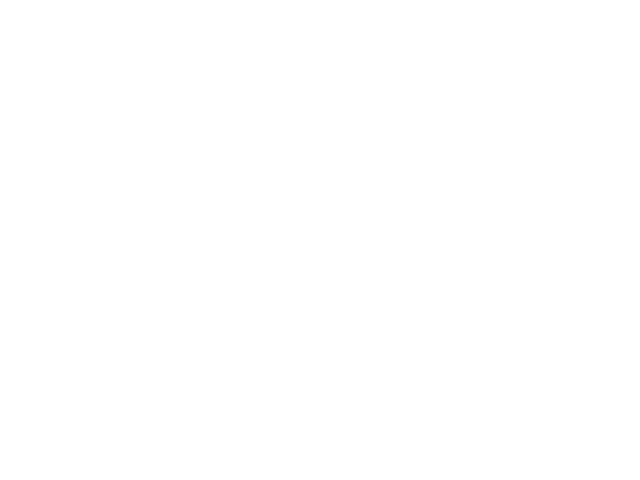

<IPython.core.display.Javascript object>


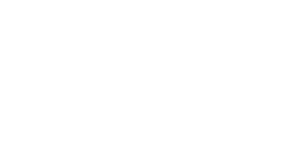

In [155]:
#new_full,tseries = synth_tseries(central_range[0])
fig = plt.figure(tight_layout=True)
fig.clear(True)
gs = gridspec.GridSpec(2, 2)

In [160]:
mat_tseries_4 = plt_mat_tseries_2(4)
osc,new_full,tseries = synth_tseries(central_range[40])
#axs = plt.figure().subplots(3,1)

ax = fig.add_subplot(gs[0,0])
ax.plot(x,osc*gauss)
ax.set_title('pulse')

#ax = fig.add_subplot(gs[:,2])
#ax.imshow(abs(new_full[:,0,:]))
#ax.set_title('spectrum vs distance')

ax = fig.add_subplot(gs[:,1])
ax.imshow(tseries[:,0,:].real)
ax.set_title('a-scan vs distance')

'''
ax = fig.add_subplot(gs[:,0])
ax.imshow(abs(new_resp))
ax.set_title('spectrum vs distance')
'''

ax = fig.add_subplot(gs[1,0])
ax.plot(np.max(abs(tseries),axis=0).transpose())
ax.set_title('max vs distance')

plt.show()

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed